# 워드 클라우드 시각화

In [13]:
from wordcloud import WordCloud  # 워드 클라우드를 그리기
from konlpy.tag import Komoran   # 형태소 분석기, 품사 태깅
from konlpy.corpus import kolaw  # 법율문서 말뭉치
import matplotlib.pyplot as plt

## 대상 텍스트(말뭉치) 다운로드

In [14]:
kolaw.fileids()

['constitution.txt']

In [15]:
para = kolaw.open('constitution.txt').read()  #대한민국 헌법 전문
type(para)

str

In [16]:
para[:100]

'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임시정부의 법통과 불의에 항거한 4·19민주이념을 계승하고, 조국의 민주개혁과 평화적 통일의'

## 형태소 분석

In [17]:
tagger = Komoran() #형태소 분석기 객체
nouns = tagger.nouns(para) #(형태소, 품사(태그)) 쌍 추출
nouns[:10] #type은 list(class)이고, len()을 통해서 3358개가 들어가 있음을 알 수 있음

['대한민국', '헌법', '역사', '전통', '국민', '운동', '건립', '대한민국', '임시', '정부']

In [18]:
len(nouns)

3358

## 문자열 타입으로 변환하기
- 워드크라우드에 넣기 위해서는 문자열타입으로 변환

In [21]:
#리스트 > 문자열
text = ",".join(nouns) #사이에 콤마로 해서 전부 다 붙여라 라는 뜻
text[:10] #나는 콤마 양 옆으로 띄어쓰기를 안해서 실습 파일과 결과값이 다름

'대한민국,헌법,역사'

## 워드 클라우드 그리기

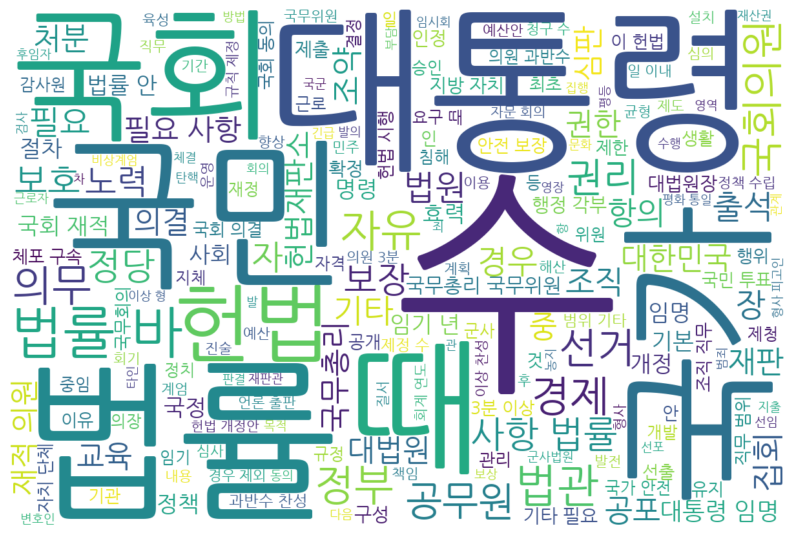

In [33]:
my_path = './fonts/NanumGothic.ttf'
fig = plt.figure(figsize = (10,10))

#워드 클라우드 객체 설정
wordcloud = WordCloud(font_path = my_path, 
                     background_color = 'white',
                     width = 1200,
                     height = 800).generate(text) #여기에 text가 앞서 저장한 값

#워드 클라우드 그리기
#plt.imshow(wordcloud) #이렇게만 실행해도 기본 저장된 형태의 이미지로 그려줌.

#interpolation='bilinear' : 이미지를 화면에 표시할 때, 픽셀 사이의 값을 보관하는 방법
plt.imshow(wordcloud, interpolation = 'bilinear') #글씨가 
plt.axis('off') #x,y축 안보이게 하기
plt.show() #출력 명령

#### interpolation='bilinear'의 의미
interpolation='bilinear'은 이미지를 화면에 표시할 때 픽셀 사이의 값을 **양선형 보간법(bilinear interpolation)** 으로 계산하여 부드럽게 렌더링하라는 의미입니다.
- 작동 원리: 워드클라우드는 본질적으로 이미지 데이터입니다. 화면에 표시할 때:
    - 원본 이미지의 픽셀 수와 화면의 픽셀 수가 다를 수 있음
    - 이미지를 확대/축소할 때 중간 값들을 어떻게 채울지 결정이 필요<br>

- Bilinear interpolation:
    - 주변 4개 픽셀의 값을 거리 기반으로 가중 평균
    - 부드러운 그라데이션 효과
    - 계단 현상(aliasing)을 줄임

- interpolation='bilinear'을 사용하면 :
    - 텍스트 경계가 부드럽게 표현됨(아닐 시, 기본 값 'antialiased' 또는 'nearest' 사용)
    - 시각적으로 더 깔끔하고 전문적(아닐 시, 픽셀이 각지게 보일 수 있음)
    - 확대/축소 시 품질 유지(아닐 시, 확대 시 계단 현상 발생)

## 이미지 모양으로 워드 크라우드 그리기
#### 마스킹하기

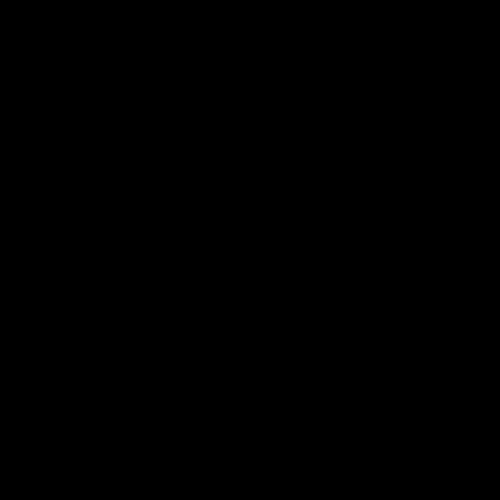

In [37]:
import numpy as np
from PIL import Image

icon = Image.open('./images/korea_map.png').convert("RGBA")
# mask = Image.new("RGB", icon.size, (255,255,255))  # 흰색
mask = Image.new("RGB", icon.size, (0,0,0))  # 검정색
mask

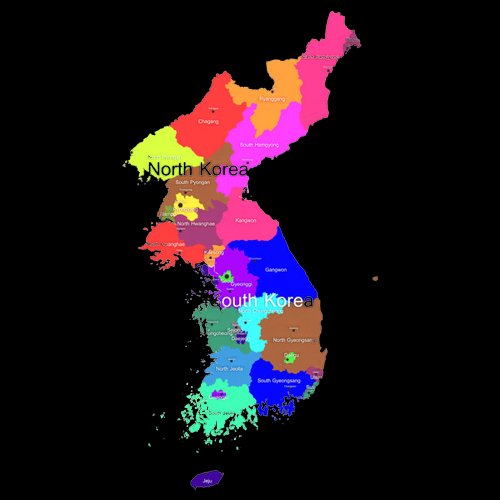

In [38]:
mask.paste(icon,icon)
mask

In [39]:
mask = np.array(mask)
mask

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(500, 500, 3), dtype=uint8)

#### 워드클라우드 그리기_지도모양

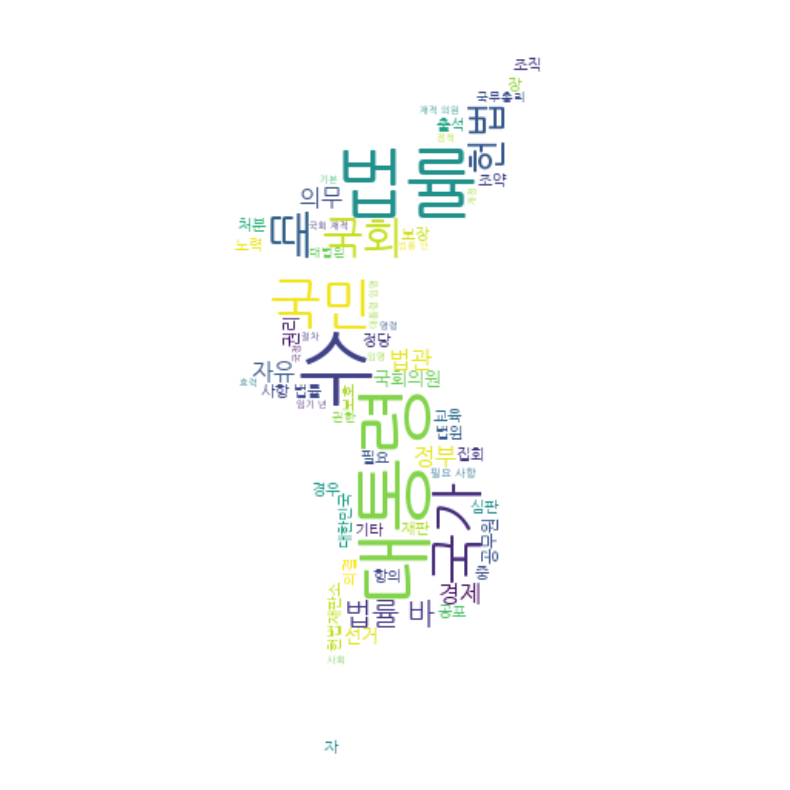

In [40]:
from PIL import Image
icon = Image.open('./images/korea_map.png').convert("RGBA")
mask = Image.new("RGB", icon.size, (255,255,255))
mask.paste(icon,icon) 
mask = np.array(mask)
wordcloud = WordCloud(font_path=my_path,
                      background_color='white',
                      width=1200,
                      height=800,
                      mask= mask).generate(text)
fig = plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

#### 워드클라우드 그리기_하트모양

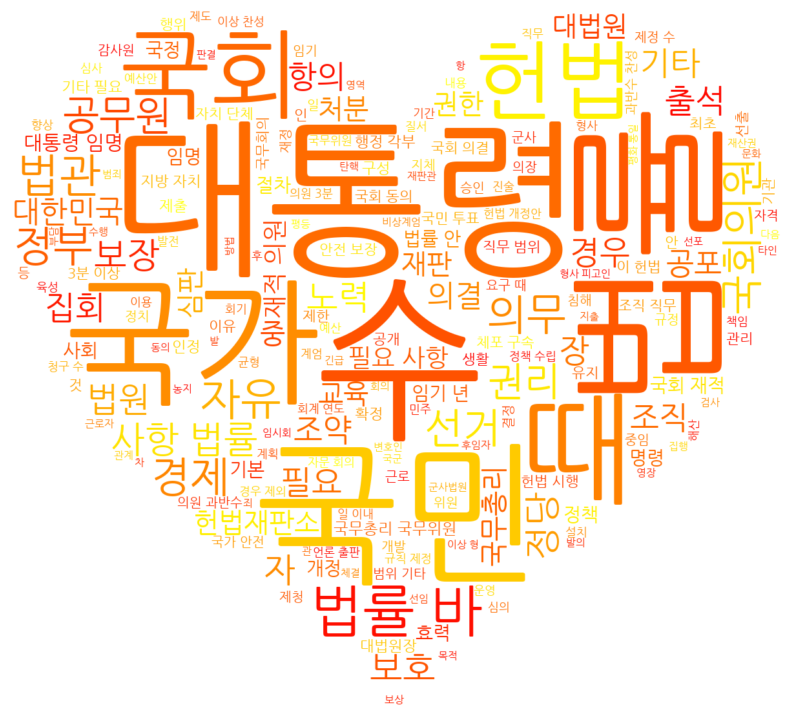

In [41]:
from PIL import Image
icon = Image.open('./images/heart.png').convert("RGBA")
mask = Image.new("RGB", icon.size, (255,255,255))
mask.paste(icon,icon) 
mask = np.array(mask)
wordcloud = WordCloud(font_path=my_path,
                      background_color='white',
                      width=1200,
                      height=800,
                      colormap='autumn',
                     mask= mask).generate(text)
fig = plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## 다른 데이터로 해보기

In [47]:
from wordcloud import WordCloud
from konlpy.tag import Komoran
import matplotlib.pyplot as plt
from konlpy.corpus import kolaw 

#### 데이터 준비

In [48]:
from Korpora import Korpora
Korpora.fetch("korsts")

[korsts] download sts-train.tsv: 1.05MB [00:00, 8.78MB/s]                                                              
[korsts] download sts-dev.tsv: 311kB [00:00, 6.58MB/s]
[korsts] download sts-test.tsv: 254kB [00:00, 4.85MB/s]


In [52]:
# Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들
# 전체 리스트 :
Korpora.corpus_list()

{'kcbert': 'beomi@github 님이 만드신 KcBERT 학습데이터',
 'korean_chatbot_data': 'songys@github 님이 만드신 챗봇 문답 데이터',
 'korean_hate_speech': '{inmoonlight,warnikchow,beomi}@github 님이 만드신 혐오댓글데이터',
 'korean_parallel_koen_news': 'jungyeul@github 님이 만드신 병렬 말뭉치',
 'korean_petitions': 'lovit@github 님이 만드신 2017.08 ~ 2019.03 청와대 청원데이터',
 'kornli': 'KakaoBrain 에서 제공하는 Natural Language Inference (NLI) 데이터',
 'korsts': 'KakaoBrain 에서 제공하는 Semantic Textual Similarity (STS) 데이터',
 'kowikitext': 'lovit@github 님이 만드신 wikitext 형식의 한국어 위키피디아 데이터',
 'namuwikitext': 'lovit@github 님이 만드신 wikitext 형식의 나무위키 데이터',
 'naver_changwon_ner': '네이버 + 창원대 NER shared task data',
 'nsmc': 'e9t@github 님이 만드신 Naver sentiment movie corpus v1.0',
 'question_pair': 'songys@github 님이 만드신 질문쌍(Paired Question v.2)',
 'modu_news': '국립국어원에서 만든 모두의 말뭉치: 뉴스 말뭉치',
 'modu_messenger': '국립국어원에서 만든 모두의 말뭉치: 메신저 말뭉치',
 'modu_mp': '국립국어원에서 만든 모두의 말뭉치: 형태 분석 말뭉치',
 'modu_ne': '국립국어원에서 만든 모두의 말뭉치: 개체명 분석 말뭉치',
 'modu_spoken': '국립국어원에서 만든 모두의 말뭉치: 구어 

In [ ]:
#Kcbert의 말뭉치를 기본 불러오기 하는 방법
#Kcbert 말뭉치 load방법 ('corpus'는 변수) :
# corpus = Korpora.load("kcbert")
# print(corpus)

#"kcbert"키를 사용했으므로, 'beomi@github 님이 만드신 KcBERT 학습데이터'를 가져온셈.


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : beomi@github
    Repository : https://github.com/Beomi/KcBERT/
    References :

    공개된 한국어 BERT는 대부분 한국어 위키, 뉴스 기사, 책 등 잘 정제된 데이터를 기반으로 학습한 모델입니다.

    한편, 실제로 NSMC와 같은 댓글형 데이터셋은 정제되지 않았고 구어체 특징에 신조어가 많으며,
    오탈자 등 공식적인 글쓰기에서 나타나지 않는 표현들이 빈번하게 등장합니다.

    KcBERT는 위와 같은 특성의 데이터셋에 적용하기 위해, 네이버 뉴스에서 댓글과 대댓글을 수집해,
    토크나이저와 BERT모델을 처음부터 학습한 Pretrained BERT 모델입니다.

    KcBERT는 Huggingface의 Transformers 라이브러리를 통해 간편히 불러와 사용할 수 있습니다.
    (별도의 파일 다운로드가 필요하지 않습니다.)

    # License
    MIT License



[kcbert] download kcbert-train.tar.gzaa:  24%|████████▉                            | 503M/2.10G [00:23<01:54, 13.9MB/s]

In [62]:
from Korpora import Korpora
corpus = Korpora.load("korsts")


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : KakaoBrain
    Repository : https://github.com/kakaobrain/KorNLUDatasets
    References :
        - Ham, J., Choe, Y. J., Park, K., Choi, I., & Soh, H. (2020). KorNLI and KorSTS: New Benchmark
           Datasets for Korean Natural Language Understanding. arXiv preprint arXiv:2004.03289.
           (https://arxiv.org/abs/2004.03289)

    This is the dataset repository for our paper
    "KorNLI and KorSTS: New Benchmark Datasets for Korean Natural Language Understanding."
    (https://arxiv.org/abs/2004.03289)
    We introduce KorNLI and KorSTS, which are NLI and STS datasets in Korean.

    # License
    Creative Commons Attribution-ShareAlike license (CC BY-SA 4.0)
    Details in https://creativecommons.org/licenses

#### 형태소 추출

In [50]:
# 말뭉치의 텍스트 부분만 추출
train_texts = corpus.train
# dev_texts = corpus.dev
# test_texts = corpus.
train_texts = train_texts.texts

# 말뭉치를 텍스트로 만들기
text_corpus = " ".join(train_texts)
print(type(text_corpus))
text_corpus[:200]

<class 'str'>


'비행기가 이륙하고 있다. 한 남자가 큰 플루트를 연주하고 있다. 한 남자가 피자에 치즈를 뿌려놓고 있다. 세 남자가 체스를 하고 있다. 한 남자가 첼로를 연주하고 있다. 몇몇 남자들이 싸우고 있다. 남자가 담배를 피우고 있다. 남자가 피아노를 치고 있다. 한 남자가 기타를 치고 노래를 부르고 있다. 사람이 고양이를 천장에 던지고 있다. 그 남자는 다른 남자'